<a href="https://colab.research.google.com/github/kwanda2426/projects/blob/main/geospatial/HW_3/Week_3_Practicals_Declustering_NSCORE_VAR_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import libraries

In [ ]:
!pip install geostatspy statsmodels geostatsmodels numba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 3.0 MB/s eta 0:00:00


In [ ]:
import os                                                     # for file and directory operations
import numpy as np                                            # for numerical operations and ndarrays
import pandas as pd                                           # for handling data in DataFrame format
import matplotlib.pyplot as plt                               # for plotting and visualization
from statsmodels.stats.weightstats import DescrStatsW         # for weighted statistics calculations
from scipy.optimize import curve_fit                          # for curve fitting
import geostatspy.GSLIB as GSLIB                              # GSLIB utilities, visualization, and wrapper functions
import geostatspy.geostats as geostats                        # GSLIB methods converted to Python
import geostatspy                                             # for accessing the package version and general utilities
#print('GeostatsPy version: ' + str(geostatspy.__version__))   # print the version of GeostatsPy

from tqdm import tqdm                                         # progress bar for loops
from functools import partialmethod                           # used to modify tqdm to suppress the status bar
tqdm.__init__ = partialmethod(tqdm.__init__, disable=True)    # suppress the status bar for tqdm

from matplotlib.ticker import (MultipleLocator, AutoMinorLocator) # control over axes ticks in plots
plt.rc('axes', axisbelow=True)                                # ensure grid lines are plotted below plot elements

import scipy.spatial as sp                                    # for spatial data structures and algorithms (KDTree)
import geopandas as gpd                                       # for handling geospatial data (GeoDataFrame)
from matplotlib import gridspec                               # custom subplots

# Define ignore_warnings before using it
ignore_warnings = True                                        # flag to ignore warnings

# Check and apply the warning filter
if ignore_warnings == True:
    import warnings
    warnings.filterwarnings('ignore')

from IPython.utils import io                                  # mute output from simulation

cmap = "Spectral_r"                                           # color map


# 2. Load Data

In [ ]:
#load data
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/geospatial/HW_3/CuMineBH.csv"
df = pd.read_csv(url)
df.head()


,EAST,NORTH,Cu
0,56.122424,105.841818,0.750
1,74.176970,81.483939,0.664
2,140.032424,191.491515,0.202
3,158.912121,133.599697,0.408
4,50.455455,211.942121,0.602


In [ ]:
# Data shape
df.shape
print("Data has {} rows and {} columns".format(df.shape[0],df.shape[1]))

Data has 1575 rows and 3 columns


In [ ]:
# Copper Dataframe
df_Cu = df.copy()
df_Cu.columns

Index(['EAST', 'NORTH', 'Cu'], dtype='object')

# 3. Check Descriptive Stats and Create Spatial Plot

#### Summary Statistics for Tabular Data

The table includes EAST and NORTH coordinates (meters), and Cu (ppb).

There are a lot of efficient methods to calculate summary statistics from tabular data in DataFrames.

* The describe command provides count, mean, minimum, maximum, and quartiles all in a nice data table.

* We use transpose just to flip the table so that features are on the rows and the statistics are on the columns.

In [ ]:
df_Cu.describe().T

,count,mean,std,min,25%,50%,75%,max
EAST,1575.0,255.912312,158.598035,0.000000,119.457424,237.761515,401.520303,561.063636
NORTH,1575.0,155.871652,63.364120,0.000000,113.178939,163.326061,207.209848,268.143939
Cu,1575.0,0.405832,0.230091,0.026000,0.244000,0.356000,0.522000,1.968000
declust_weight,1575.0,1.000000,0.515250,0.546464,0.653680,0.833002,1.158636,5.823890


In [ ]:
def add_grid():
    plt.gca().grid(True, which='major',linewidth = 1.0); plt.gca().grid(True, which='minor',linewidth = 0.2) # add y grids
    plt.gca().tick_params(which='major',length=7); plt.gca().tick_params(which='minor', length=4)
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator()); plt.gca().yaxis.set_minor_locator(AutoMinorLocator()) # turn on minor ticks

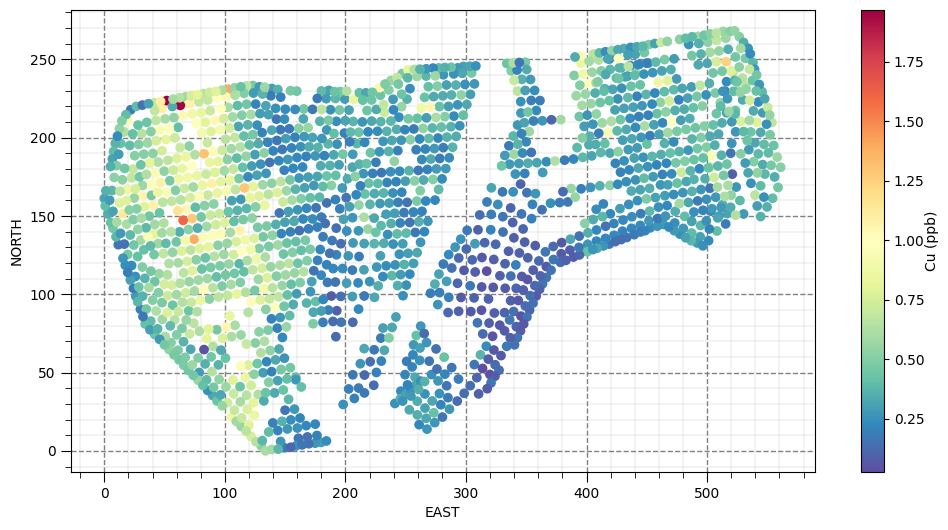

In [ ]:

# Create the figure and axis
fig, ax = plt.subplots(figsize = (12, 6))

# Create the scatter plot
sc = ax.scatter(df_Cu['EAST'], df_Cu['NORTH'], c = df_Cu['Cu'], cmap = cmap)

# Create the grid
ax.grid(True, color = 'grey', linestyle = '--', linewidth = 0.5)

# Add labels to the axes
ax.set_xlabel('EAST')
ax.set_ylabel('NORTH')

# Add a colorbar
cbar = plt.colorbar(sc, ax = ax)
cbar.set_label('Cu (ppb)', rotation = 90, labelpad = 0)
cbar.ax.tick_params(labelsize=10)
add_grid()


# Display the plot
plt.show()


# 4. Decluster Samples

In [ ]:
df_Cu["declust_weight"], cell_size, declust_means = geostats.declus(df_Cu,'EAST','NORTH','Cu',iminmax = 1, noff = 25, ncell = 200,cmin = 1,cmax = 750)

There are 1575 data with:
   mean of      0.405832380952381 
   min and max  0.026 and 1.968
   standard dev 0.23001832880532494 


Now let's look at the plot of the declustered porosity mean vs. the declustering cell size over the 100 runs. At very small and very large cell size the declustered mean is the naive mean.

naive mean = 0.406
declustered mean = 0.38


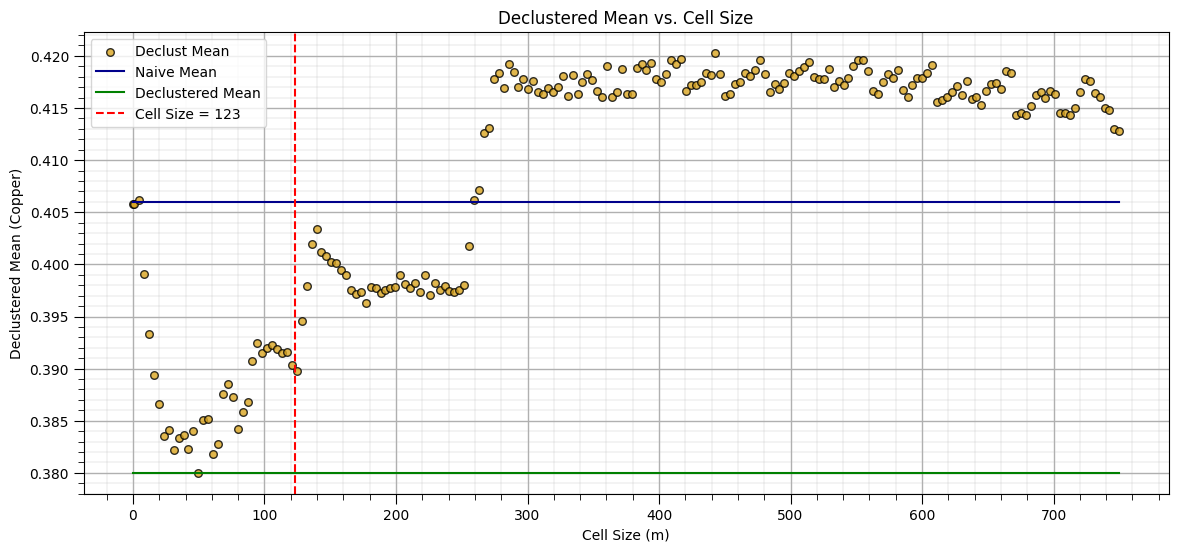

In [ ]:
# Calculating the weighted mean (declustered mean)
weighted_data = DescrStatsW(df_Cu["Cu"].values, weights = df_Cu["declust_weight"].values, ddof = 0)
dmean = round(weighted_data.mean, 3)

# Calculating the naive mean for comparison
naive_mean = round(np.mean(df_Cu["Cu"].values), 3)
print("naive mean = " +str(naive_mean))
print("declustered mean = " +str(dmean))
# Create a scatter plot
plt.figure(figsize = (14, 6))
plt.scatter(cell_size, declust_means, s = 30, alpha = 0.8, edgecolors = "black", facecolors = 'goldenrod', label = 'Declust Mean')
plt.plot(cell_size, [naive_mean] * len(cell_size), color = 'darkblue', label = 'Naive Mean')
plt.plot(cell_size, [dmean] * len(cell_size), color = 'green', label = 'Declustered Mean')

# Plotting a vertical red dotted line at cell size 123
plt.axvline(x = 123, color = 'red', linestyle = '--', label = 'Cell Size = 123')

# Labels, title, and grid
plt.xlabel('Cell Size (m)')
plt.ylabel('Declustered Mean (Copper)')
plt.title('Declustered Mean vs. Cell Size')

plt.legend()
add_grid()

# Show the plot
plt.show()


In [ ]:
df_Cu.head(3)

,EAST,NORTH,Cu,declust_weight
0,56.122424,105.841818,0.750,0.629259
1,74.176970,81.483939,0.664,0.691547
2,140.032424,191.491515,0.202,0.628520


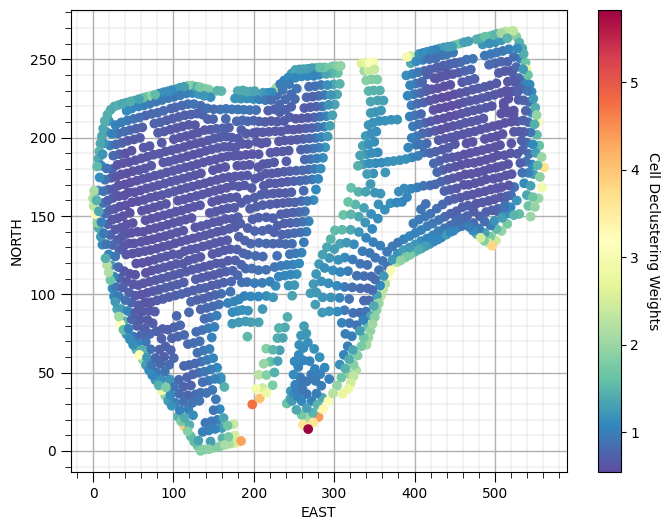

In [ ]:

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Create the scatter plot
sc = ax.scatter(df_Cu['EAST'], df_Cu['NORTH'], c = df_Cu['declust_weight'], cmap = 'Spectral_r')


# Add labels to the axes
ax.set_xlabel('EAST')
ax.set_ylabel('NORTH')

# Add a colorbar
cbar = plt.colorbar(sc, ax = ax)
cbar.set_label('Cell Declustering Weights', rotation = 270, labelpad = 15)
cbar.ax.tick_params(labelsize=10)
add_grid()


# Display the plot
plt.show()


In [ ]:
# Calculate naive statistics
naive_stats = df_Cu['Cu'].describe(percentiles = [0.25, 0.75])

# Calculate declustered statistics using weighted statistics
declust_mean = weighted_data.mean
declust_min = np.min(df_Cu['Cu'].values)
declust_q1 = weighted_data.quantile(0.25).item()  # Convert to scalar using item()
declust_q3 = weighted_data.quantile(0.75).item()  # Convert to scalar using item()
declust_max = np.max(df_Cu['Cu'].values)

# Construct the table data
table_data = {
    "Arsenic Data": ["Naive", "Declustered", "Difference"],
    "Min [ppb]": [round(naive_stats['min'], 2), round(declust_min, 2), round(declust_min - naive_stats['min'], 2)],
    "Q1 [ppb]": [round(naive_stats['25%'], 2), round(declust_q1, 2), round(declust_q1 - naive_stats['25%'], 2)],
    "Mean [ppb]": [round(naive_stats['mean'], 2), round(declust_mean, 2), round(declust_mean - naive_stats['mean'], 2)],
    "Q3 [ppb]": [round(naive_stats['75%'], 2), round(declust_q3, 2), round(declust_q3 - naive_stats['75%'], 2)],
    "Max [ppb]": [round(naive_stats['max'], 2), round(declust_max, 2), round(declust_max - naive_stats['max'], 2)]
}

# Create a DataFrame for the table
summary_table_df = pd.DataFrame(table_data)
summary_table_df


,Arsenic Data,Min [ppb],Q1 [ppb],Mean [ppb],Q3 [ppb],Max [ppb]
0,Naive,0.03,0.24,0.41,0.52,1.97
1,Declustered,0.03,0.23,0.38,0.49,1.97
2,Difference,0.00,-0.02,-0.03,-0.03,0.00


# 5. Transform Data to Gaussian Space

In [ ]:
df_Cu["nscore"], tv, tns = geostats.nscore(df_Cu, "Cu", "declust_weight")
df_Cu

,EAST,NORTH,Cu,declust_weight,nscore
0,56.122424,105.841818,0.750,0.629259,1.503291
1,74.176970,81.483939,0.664,0.691547,1.241768
2,140.032424,191.491515,0.202,0.628520,-0.848610
3,158.912121,133.599697,0.408,0.649817,0.354469
4,50.455455,211.942121,0.602,0.882198,1.065064
...,...,...,...,...,...
1570,262.855151,218.851818,0.872,0.690122,1.851168
1571,115.157576,147.677576,0.466,0.621053,0.591472
1572,243.885758,234.132727,0.464,0.976757,0.580693
1573,148.234545,158.911818,0.712,0.627234,1.423534


In [ ]:
feature = "Cu"
feature_units = "ppb"
vmin = df_Cu["Cu"].min()
vmax = df_Cu["Cu"].max()
xmin = df_Cu["EAST"].min()
xmax = df_Cu["EAST"].max()
ymin = df_Cu["NORTH"].min()
ymax = df_Cu["NORTH"].max()

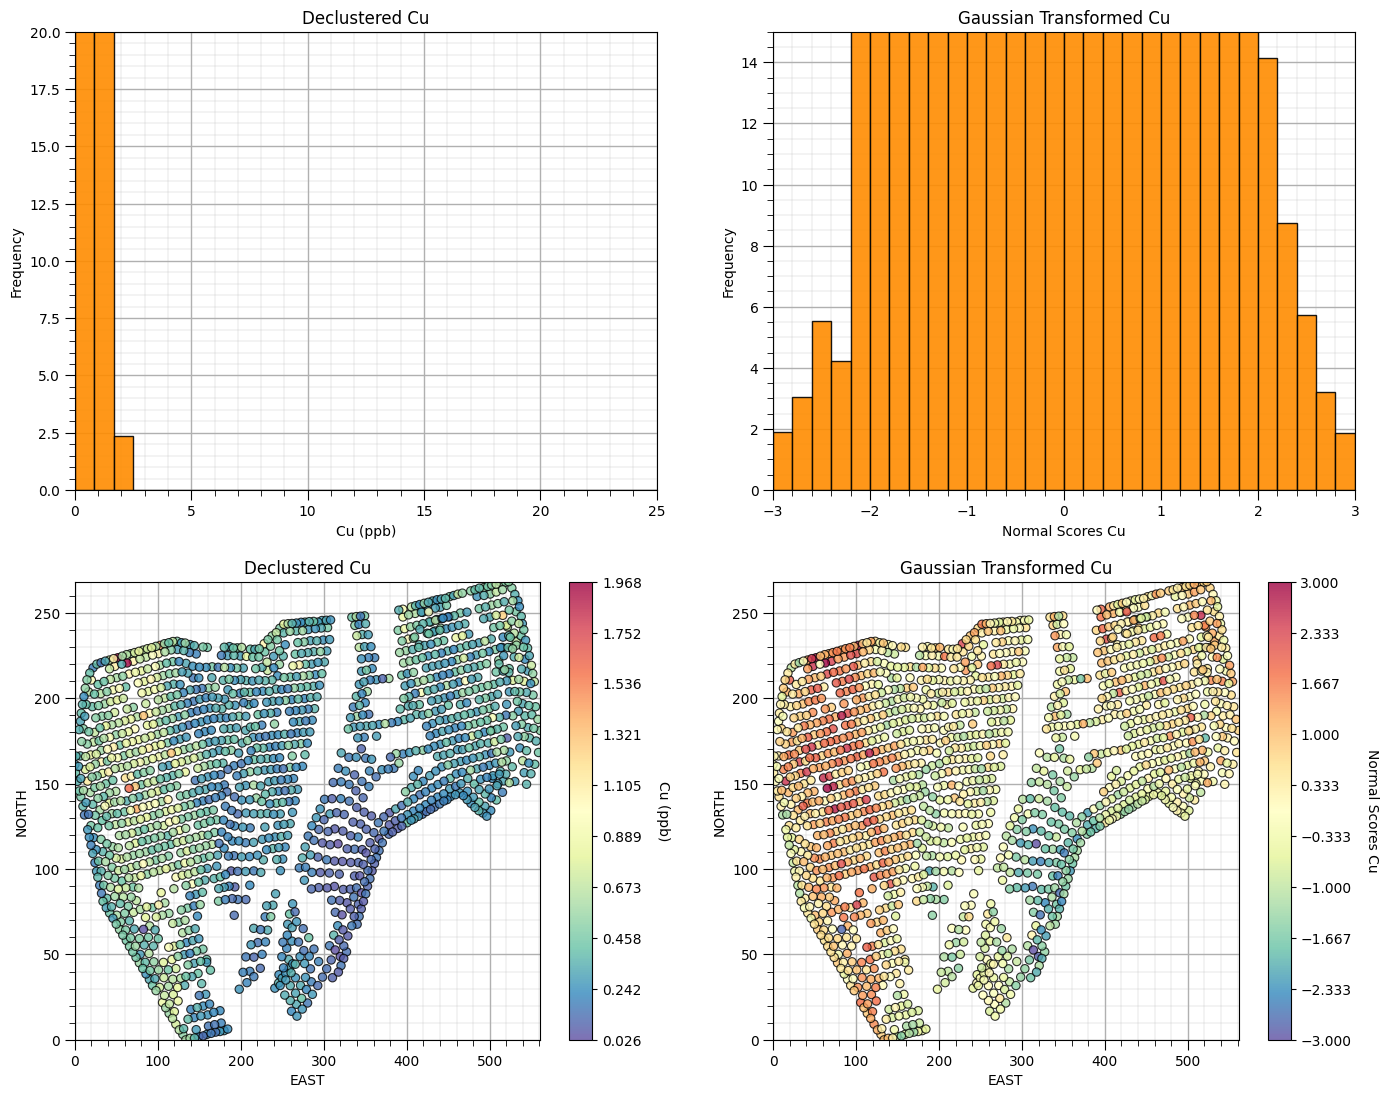

In [ ]:
plt.subplot(221)
GSLIB.hist_st(df_Cu['Cu'],0,25,log = False,cumul = False,bins = 30,weights = df_Cu['declust_weight'],xlabel = "Cu (ppb)",title = "Declustered Cu")
plt.ylim(0.0,20)
add_grid()
plt.subplot(222)
GSLIB.hist_st(df_Cu['nscore'],-3.0,3.0,log=False,cumul = False,bins = 30,weights = df_Cu['declust_weight'],xlabel = "Normal Scores Cu",title = "Gaussian Transformed Cu")
plt.ylim(0.0,15)
add_grid()
plt.subplot(223)
GSLIB.locmap_st(df_Cu,'EAST','NORTH','Cu',xmin,xmax,ymin,ymax,vmin,vmax,'Declustered Cu','EAST','NORTH','Cu (ppb)',cmap)
add_grid()
plt.subplot(224)
GSLIB.locmap_st(df_Cu,'EAST','NORTH','nscore',xmin,xmax,ymin,ymax,-3.0,3.0,'Gaussian Transformed Cu','EAST','NORTH','Normal Scores Cu',cmap)
add_grid()
plt.subplots_adjust(left = 0.0, bottom = 0.0, right = 2.0, top = 2.1, wspace = 0.2, hspace = 0.2)
plt.show()

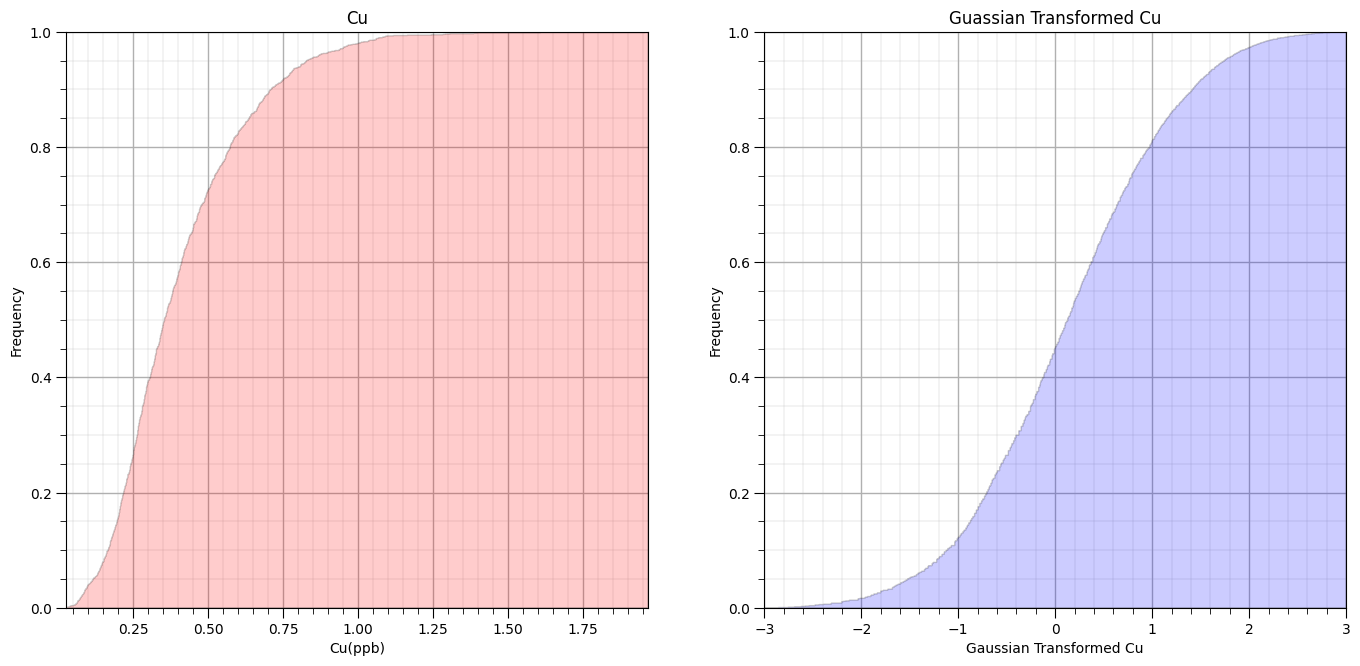

In [ ]:
plt.subplot(121)

plt.hist(df_Cu[feature], facecolor = 'red',bins = np.linspace(vmin,vmax,1000),histtype = "stepfilled",alpha = 0.2,density = True,cumulative = True,edgecolor = 'black')
plt.xlim([vmin,vmax]); plt.ylim([0,1.0])
plt.xlabel(feature + '(' + feature_units + ')'); plt.ylabel('Frequency'); plt.title('Cu')
add_grid()

plt.subplot(122)
plt.hist(df_Cu['nscore'], facecolor = 'blue',bins = np.linspace(-3.0,3.0,1000),histtype = "stepfilled",alpha = 0.2,density = True,cumulative = True,edgecolor = 'black')
plt.xlim([-3.0,3.0]); plt.ylim([0,1.0])
plt.xlabel('Gaussian Transformed ' + feature); plt.ylabel('Frequency'); plt.title('Guassian Transformed ' + feature)
add_grid()

plt.subplots_adjust(left = 0.0, bottom = 0.0, right = 2.0, top = 1.2, wspace = 0.2, hspace = 0.3)
plt.show()

## P-value?




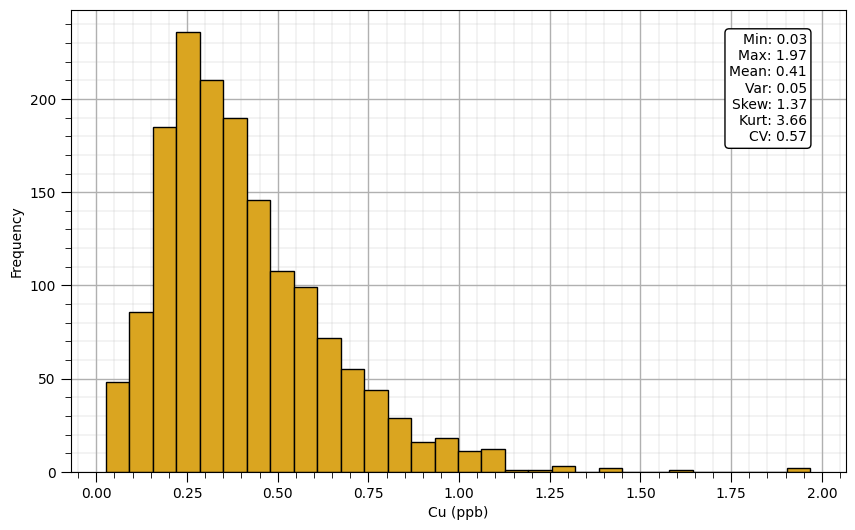

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew

# Calculate statistics
Cu_data = df_Cu["Cu"]
min_val = np.min(Cu_data)
max_val = np.max(Cu_data)
mean_val = np.mean(Cu_data)
var_val = np.var(Cu_data)
skew_val = skew(Cu_data)
kurt_val = kurtosis(Cu_data)
cv_val = np.std(Cu_data) / mean_val

# Prepare the stats text
stats_text = (f"Min: {min_val:.2f}\n"
              f"Max: {max_val:.2f}\n"
              f"Mean: {mean_val:.2f}\n"
              f"Var: {var_val:.2f}\n"
              f"Skew: {skew_val:.2f}\n"
              f"Kurt: {kurt_val:.2f}\n"
              f"CV: {cv_val:.2f}")

# Create the figure
fig, ax = plt.subplots(figsize = (10, 6))

# Plot the histogram
ax.hist(Cu_data, bins = 30, edgecolor = "black", color = "goldenrod")

ax.set_xlabel("Cu (ppb)")
ax.set_ylabel("Frequency")

# Add the stats text box
ax.text(0.95, 0.95, stats_text, transform = ax.transAxes, fontsize = 10,
        verticalalignment = 'top', horizontalalignment = 'right',
        bbox = dict(boxstyle = "round,pad=0.3", edgecolor = "black", facecolor = "white"))
add_grid()


# Show the plot
plt.show()


In [ ]:
from scipy.stats import normaltest

# Assuming df_Cu is defined and contains the "nscore" column
raw_data = df_Cu["Cu"]

# Perform the normality test (D'Agostino and Pearson's test)
stat, p_value = normaltest(raw_data)

# Define the hypothesis result
alpha = 0.05
if p_value > alpha:
    result = "Fail to reject the null hypothesis (Cu grade is Gaussian)."
else:
    result = "Reject the null hypothesis (Cu grade is not Gaussian)."

p_value, result


(np.float64(2.266311805277066e-95),
 'Reject the null hypothesis (Cu grade is not Gaussian).')

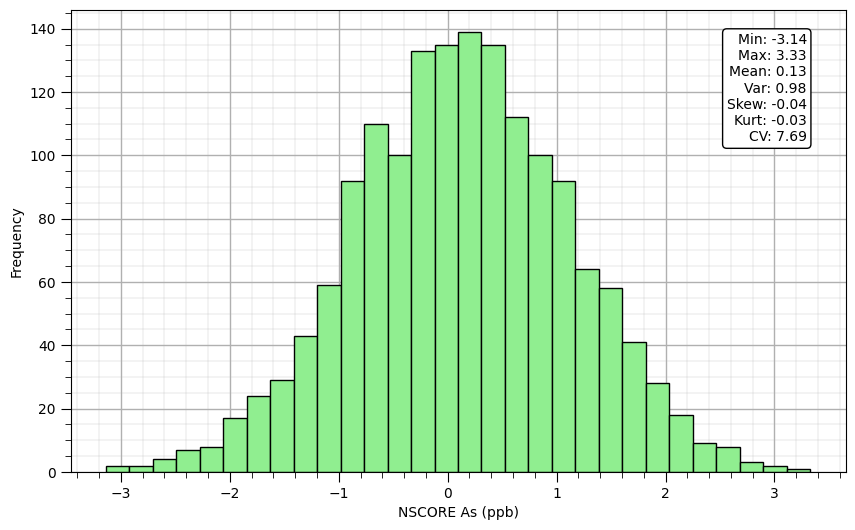

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew

# Calculate statistics for the "nscore" column
nscore_data = df_Cu["nscore"]
min_val = np.min(nscore_data)
max_val = np.max(nscore_data)
mean_val = np.mean(nscore_data)
var_val = np.var(nscore_data)
skew_val = skew(nscore_data)
kurt_val = kurtosis(nscore_data)
cv_val = np.std(nscore_data) / mean_val

# Prepare the stats text
stats_text = (f"Min: {min_val:.2f}\n"
              f"Max: {max_val:.2f}\n"
              f"Mean: {mean_val:.2f}\n"
              f"Var: {var_val:.2f}\n"
              f"Skew: {skew_val:.2f}\n"
              f"Kurt: {kurt_val:.2f}\n"
              f"CV: {cv_val:.2f}")

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the histogram
ax.hist(nscore_data, bins = 30, edgecolor = "black", color = "lightgreen")

ax.set_xlabel("NSCORE As (ppb)")
ax.set_ylabel("Frequency")

# Add the stats text box
ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment = 'top', horizontalalignment = 'right',
        bbox=dict(boxstyle = "round,pad=0.3", edgecolor = "black", facecolor = "white"))
add_grid()

# Show the plot
plt.show()


In [ ]:
from scipy.stats import normaltest

# df_Cu is defined and contains the "nscore" column
nscore_data = df_Cu["nscore"]

# Perform the normality test (D'Agostino and Pearson's test)
stat, p_value = normaltest(nscore_data)

# Define the hypothesis result
alpha = 0.05
if p_value > alpha:
    result = "Fail to reject the null hypothesis (nscore is Gaussian)."
else:
    result = "Reject the null hypothesis (nscore is not Gaussian)."

p_value, result


(np.float64(0.8060925966602379),
 'Fail to reject the null hypothesis (nscore is Gaussian).')

# 6. Variogram

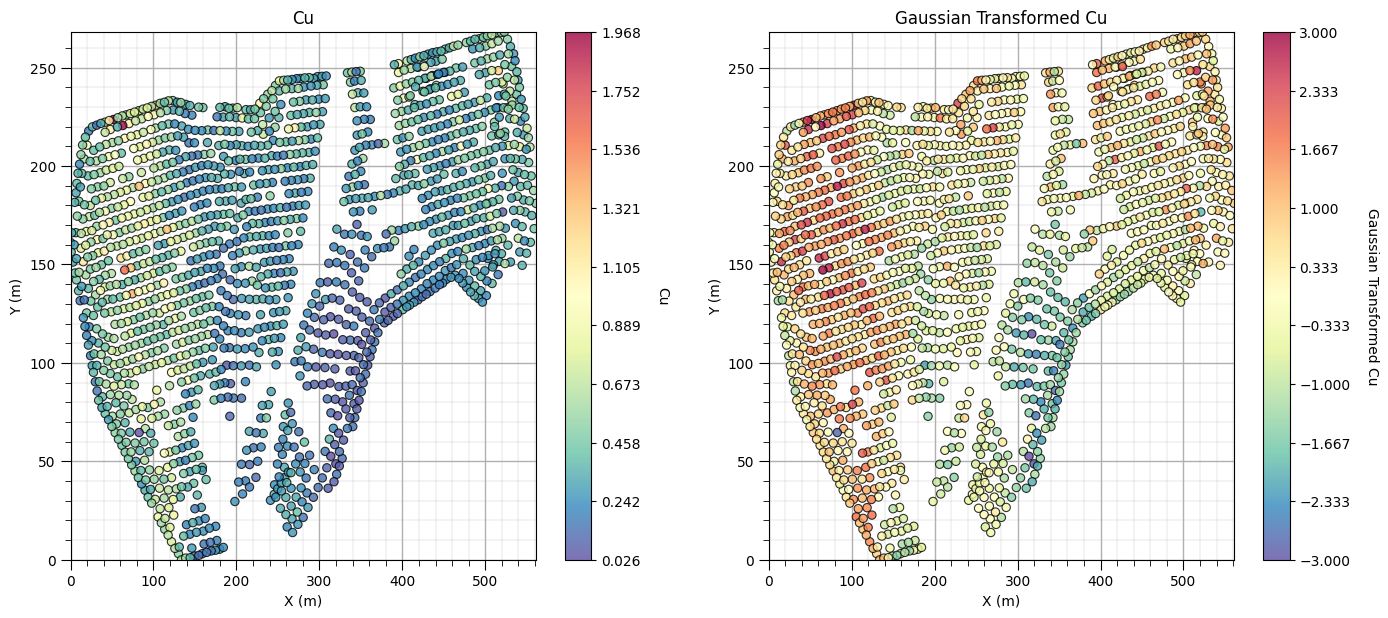

In [ ]:
cmap = "Spectral_r"
plt.subplot(121)                                        # location map of normal score transform of ore grade
GSLIB.locmap_st(df_Cu,'EAST','NORTH',feature,xmin,xmax,ymin,ymax,vmin,vmax,feature,'X (m)','Y (m)',feature,cmap)
add_grid()
plt.subplot(122)                                        # location map of normal score transform of ore grade
GSLIB.locmap_st(df_Cu,'EAST','NORTH','nscore',xmin,xmax,ymin,ymax,-3,3,'Gaussian Transformed ' + feature,'X (m)','Y (m)','Gaussian Transformed ' + feature,cmap)
add_grid()
plt.subplots_adjust(left = 0.0, bottom = 0.0, right = 2.0, top = 1.1, wspace = 0.2, hspace = 0.3); plt.show()

#### Method \#2: Variogram Maps

Let's try out variogram maps.
The inputs include:

* **input data** - DataFrame, 'df', and columns for x, y and property of interest, 'x', 'y' and 'vcol',
* **variogram map parameters** - number of cells in each direction to search, 'nxlag', nylag', the cell size / lag distance, 'dxlag' and 'dylag'''
* **search** - the minimum number of pairs reuqired to assign a result, 'mnpairs'
* **normalization** - 1 for standardize variance to 1.0 and 0 for not

The output is a 2D ndarray with the variogram map and the number of pairs.

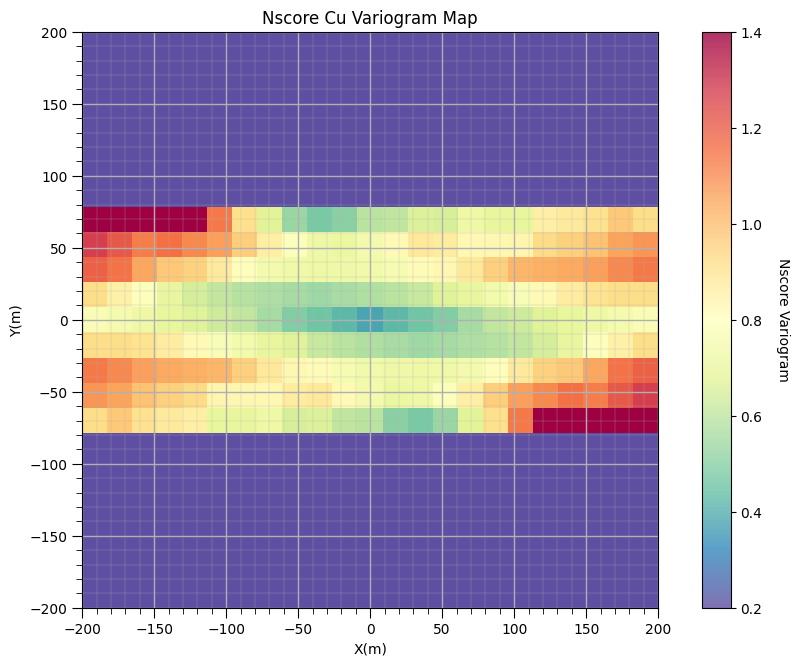

The shape of the output is (23, 23)


In [ ]:
vmap, npmap = geostats.varmapv(df_Cu,'EAST','NORTH','nscore',tmin = -9999,tmax = 9999,nxlag = 11,nylag = 11,dxlag = 7,dylag = 50,minnp = 1,isill = 1)

plt.subplot(121)
GSLIB.pixelplt_st(vmap,-200,200,-200,200,50.0,0.2,1.4,'Nscore Cu Variogram Map','X(m)','Y(m)','Nscore Variogram',cmap)
add_grid()
plt.subplots_adjust(left = 0.0, bottom = 0.0, right = 3.0, top = 1.2, wspace = 0.2, hspace = 0.2)
plt.show()

print('The shape of the output is ' + str(vmap.shape))

Notice that the output ndarray is 23, 23 cells? We asked for the number of cells to extend in each direction, 11 and 11 in x and y.  The map has an origin (zero distance) cell in the middle and extends 11 in both positive and negative directions.  So we have 2*$nx$ + 1, 2*$ny$ + 1 cells in the resulting variogram map and the $xmin = -1 * (nx * x_{cellsize} + \frac{1}{2} x_{cellsize})$ and the $xmax = nx * x_{cellsize} + \frac{1}{2} x_{cellsize}$

What do you think of this variogram map? These are my observations:

* major continuity direction is at azimuth 045
* there is a high degree of geometric anisotropy
* there is cyclicity in the 135 direction
* there may be some cyclicity in the 045 direction

From this variogram map we can immediately see directionality in our spatial data.

#### Method \#3: Experimental Variograms

Another method for exploring spatial data directionality is the calculation of multiple experimental variograms for a variety of directions.

We can use the location maps to help determine good variogram calculation parameters.

```p
tmin = -9999.; tmax = 9999.;
lag_dist = 100.0; lag_tol = 50.0; nlag = 7; bandh = 9999.9; azi = azi; atol = 22.5; isill = 1
```
* **tmin**, **tmax** are trimming limits - set to have no impact, no need to filter the data
* **lag_dist**, **lag_tol** are the lag distance, lag tolerance - set based on the common data spacing (100m) and tolerance as 100% of lag distance for additonal smoothing
* **nlag** is number of lags - set to extend just past 50 of the data extent
* **bandh** is the horizontal band width - set to have no effect
* **azi** is the azimuth -  it has not effect since we set atol, the azimuth tolerance, to 90.0
* **isill** is a boolean to standardize the distribution to a variance of 1 - it has no effect since the nscore transform sets the variance to 1.0

In [ ]:
tmin = -9999.; tmax = 9999.                             # no trimming
lag_dist = 30.0; lag_tol = lag_dist*0.5; nlag = 40;            # maximum lag is 700m and tolerance > 1/2 lag distance for smoothing
bandh = 30; atol = 22.5                             # no bandwidth, directional variograms
isill = 1                                               # standardize sill
azi_mat = [0,22.5,45,67.5,90,112.5,135,157.5]           # directions in azimuth to consider

Let's try running these variograms and visualizing them on separate plots.  I'll demonstrate a method to promgramtically loop over each direction for efficiency (and code brevity).

* we have the direction in the list called 'azi_mat'
* we use the command:
```p
for iazi in range(0,len(azi_mat)):
```
to loop over all the elements in the list with index 'iazi'

* we run the variogram calculation and store the reuslts in 2D arrays, iy is direction, ix is the lag
* we use subplots with the 'iazi' index to add each plot

```p
    plt.subplot(4,2,iazi+1)
```
we add one because the plot index must be $1,\ldots,n$, but arrays / list index as $0,\ldots,n-1$ in Python.

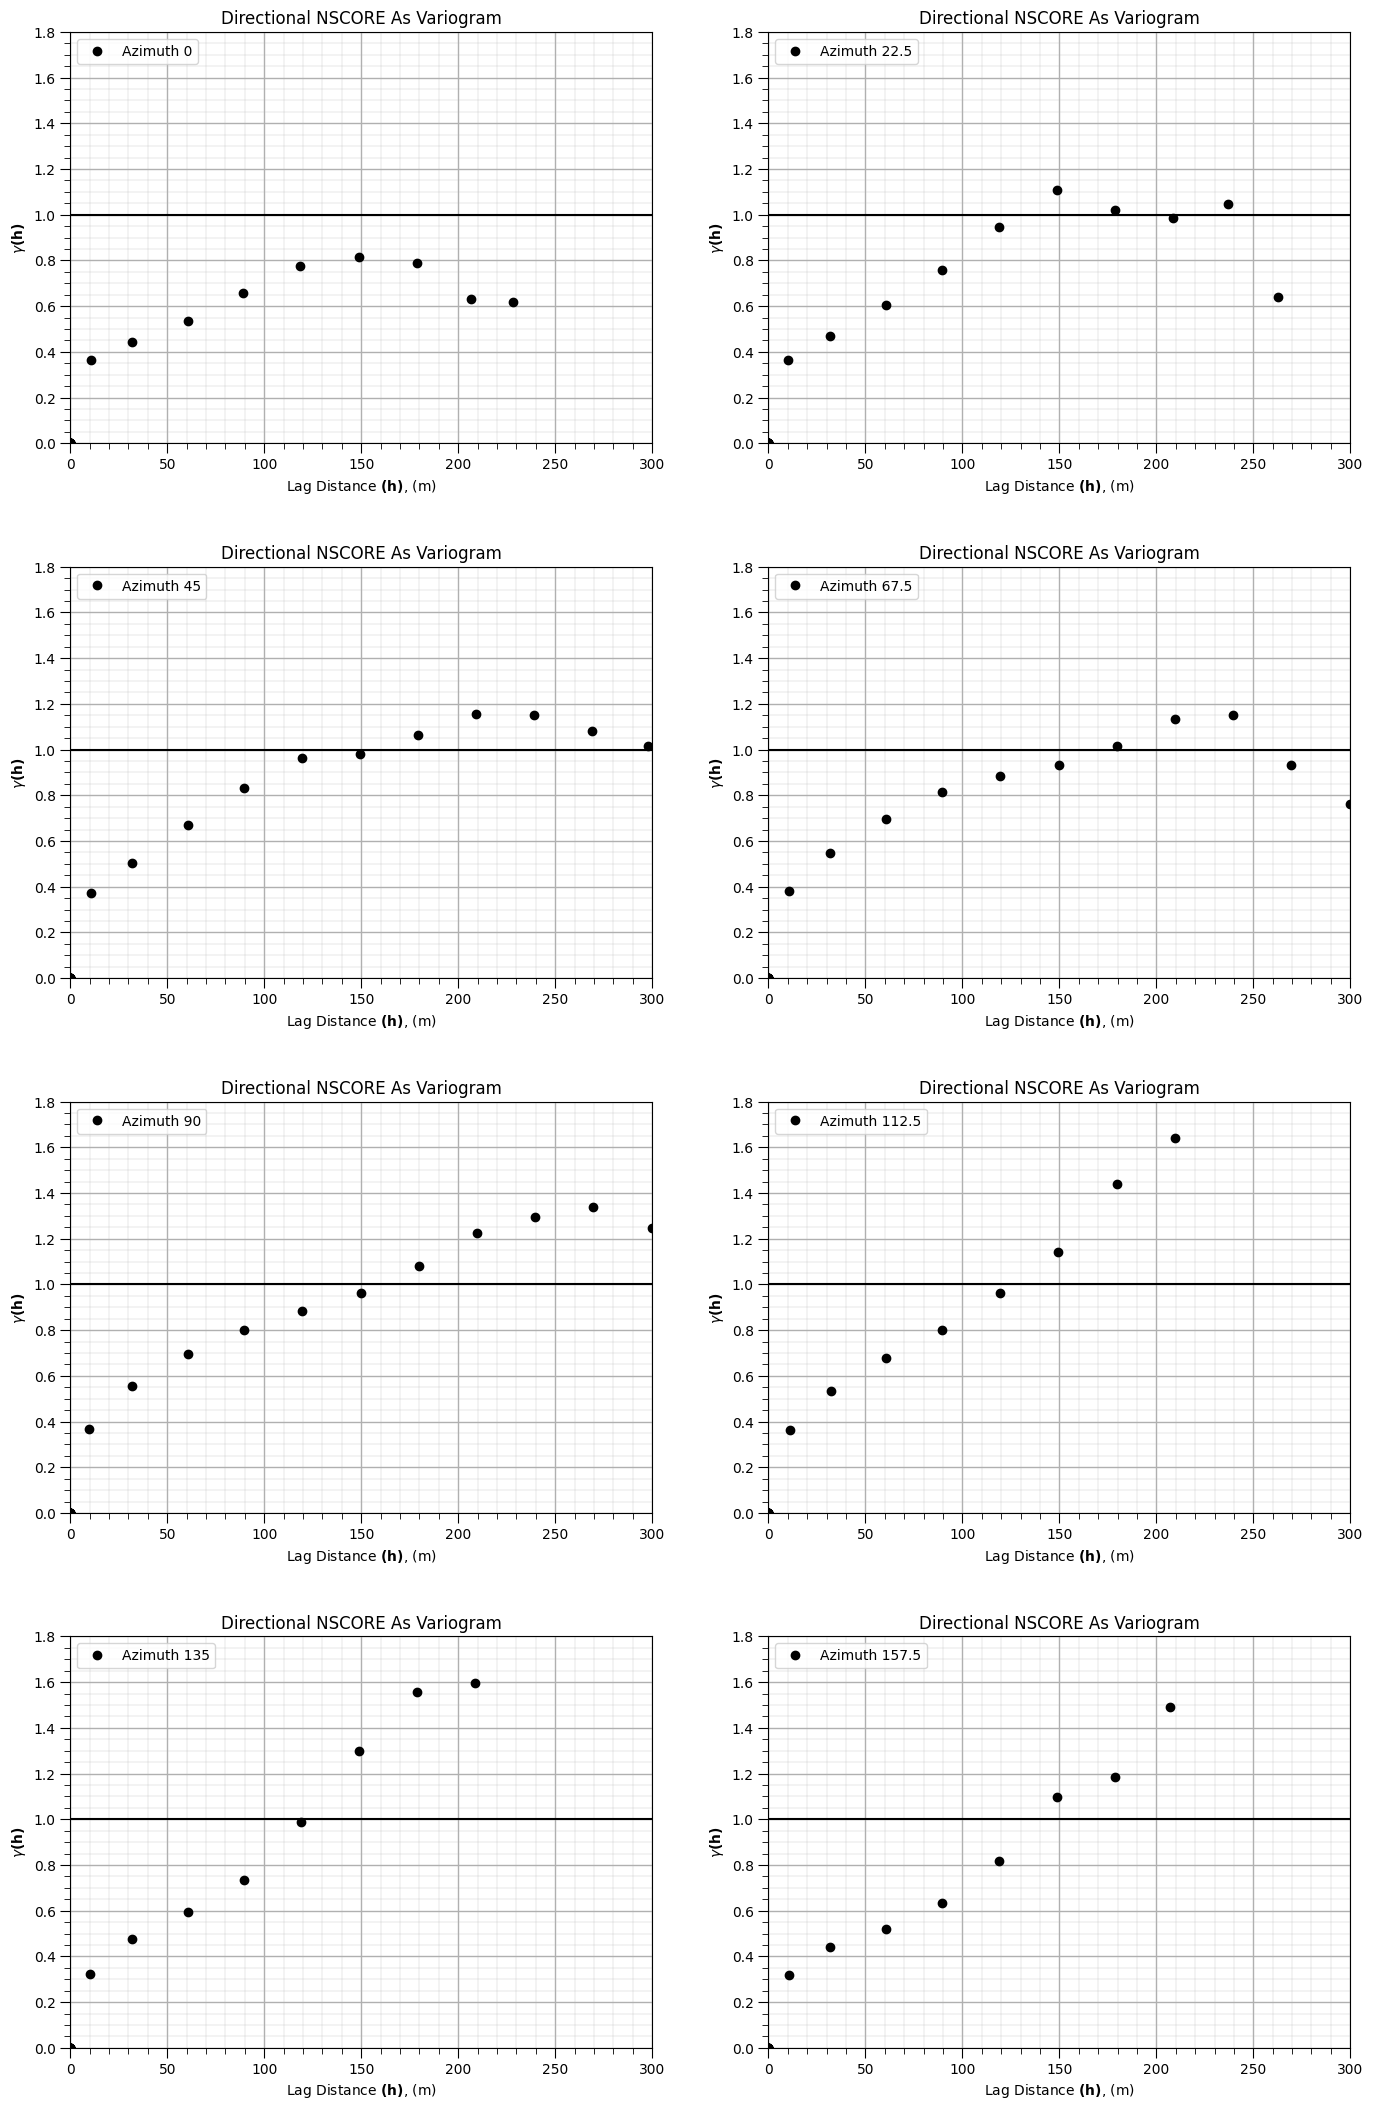

In [ ]:
# Arrays to store the results
lag = np.zeros((len(azi_mat),nlag+2)); gamma = np.zeros((len(azi_mat),nlag+2)); npp = np.zeros((len(azi_mat),nlag+2));

for iazi in range(0,len(azi_mat)):                      # Loop over all directions
    lag[iazi,:], gamma[iazi,:], npp[iazi,:] = geostats.gamv(df_Cu,"EAST","NORTH","nscore",tmin,tmax,lag_dist,lag_tol,nlag,azi_mat[iazi],atol,bandh,isill)
    plt.subplot(4,2,iazi+1)
    plt.plot(lag[iazi,:],gamma[iazi,:],'o',color = 'black',label = 'Azimuth ' +str(azi_mat[iazi]))
    plt.plot([0,2000],[1.0,1.0],color = 'black')
    plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
    plt.ylabel(r'$\gamma \bf(h)$')
    plt.title('Directional NSCORE As Variogram')
    plt.xlim([0,300])
    plt.ylim([0,1.8])
    plt.legend(loc='upper left')
    add_grid()

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=4.2, wspace=0.2, hspace=0.3)
plt.show()

The directional variograms provide a very clear image of directionality. The ranges vary in different directions.  We are observing the actually spatial continuity ellipse by exploring a variety of directions!

* We can observe that Azimuth 000 is the major direction and Azimuth 090 is the minor direction.

This is a very powerful tool for exploring directionality in spatial datasets.

#### Variogram Modeling

From above we can identify 045 as the major direction and 135 as the minor direction. We must build a single 2D nested variogram model based on the experiential variograms in each 045 and 135 directions.  First, let's look at these two experimental variograms again.

Below edit the following code to select the major and minor directions from the plots above.  

```python
# Select the plot above for the major and minor
imajor = 0
iminor = 4
```

Note the first plot is 0 and then step through $0, 1, \ldots, n$ where $n$ is the number of directional variograms calculated above.  For the provided example we selected the plots, 0th (000 Azimuth) for the major direction and the 4th (090 Azimuth) for the minor direction.

Major direction is 45 azimuth.
Minor direction is 135 azimuth.


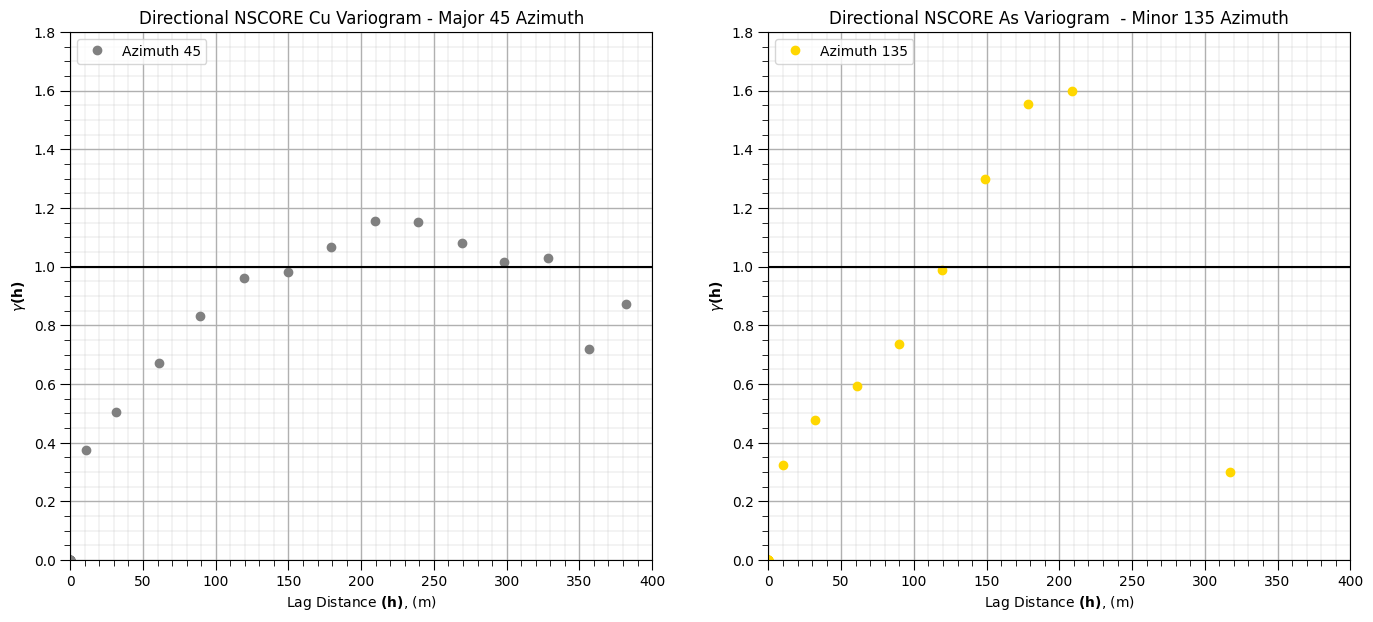

In [ ]:
# Select the plot above for the major and minor
imajor = 2
iminor = 6

print('Major direction is ' + str(azi_mat[imajor]) + ' azimuth.')
print('Minor direction is ' + str(azi_mat[iminor]) + ' azimuth.')

if not abs(azi_mat[imajor] - azi_mat[iminor]) == 90.0:
    print('Major and minor directions must be orthogonal to each other.')
    sys.exit()

plt.subplot(1,2,1)
plt.plot(lag[imajor,:],gamma[imajor,:],'o',color = 'grey',label = 'Azimuth ' + str(azi_mat[imajor]))
plt.plot([0,2000],[1.0,1.0],color = 'black')
plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Directional NSCORE Cu Variogram - Major ' + str(azi_mat[imajor]) + ' Azimuth')
plt.xlim([0,400])
plt.ylim([0,1.8])
plt.legend(loc='upper left')
add_grid()
plt.subplot(1,2,2)
plt.plot(lag[iminor,:],gamma[iminor,:],'o',color = 'gold',label = 'Azimuth ' +str(azi_mat[iminor]))
plt.plot([0,2000],[1.0,1.0],color = 'black')
plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Directional NSCORE As Variogram  - Minor ' + str(azi_mat[iminor]) + ' Azimuth')
plt.xlim([0,400])
plt.ylim([0,1.8])
plt.legend(loc='upper left')
add_grid()
plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=1.1, wspace=0.2, hspace=0.3); plt.show()

We will assume these models will be applied in sequential Gaussian simulation; therefore, we must model to the sill (or the global distribution will not be reproduced over the realizations).  We will also not use cyclicity for now, as we are just getting started.  

* Let's build a reasonable model to the sill.

##### make_variogram function

We use the make_variogram function to make a variogram model

* a dictionary for compact storage of the variogram model parameters to pass into plotting (below), kriging and simulation methods

The variogram model parameter include:

* **nug** - nugget effect contribution to sill
* **nst** - number of nested structures (1 or 2)
* **it** - type for this nested structure (1 - spherical, 2 - exponential, 3 - Gaussian)
* **cc** - contribution of each nested structure (contributions + nugget must sum to the sill)
* **azi** - the azimuth for this nested structure of the major direction, the minor is orthogonal
* **hmaj** - the range for this nested structure in the major direction
* **hmin** - the range for this nested structure in the minor direction

We increment it, cc, azi, hmaj, and hmin for the 1st and 2nd structures

* for only 1 structure plus optional nugget, omit the 2nd structure parameters and they will default to $cc2 = 0$, no contribution to the model

Here's my model:

```p
nug = 0.3; nst = 2                                             # 2 nest structure variogram model parameters
it1 = 1; cc1 = 0.2; azi1 = azi_mat[imajor]; hmaj1 = 120; hmin1 = 70 #first structure
it2 = 1; cc2 = 0.5; azi2 = azi_mat[imajor]; hmaj2 = 370; hmin2 = 200 #second structure
```

Some comments on our model:

* we model to the sill of 1.0, since we applied the normal score transform ($nug + cc1 + cc2 = 1.0$)

* we used 2 spherical structures to capture zontal anisotropy in the 045 azimuth

* since the experimental variogram exceeds the sill with trend or cyclicity we could have attempted trend modeling and then worked with the residual, but we will not do this for workflow brevity and simplicity

We input these model parameters to make a variogram model dictionary with the make_variogram function as follows:

```p
vario = GSLIB.make_variogram(nug,nst,it1,cc1,azi1,hmaj1,hmin1,it2,cc2,azi2,hmaj2,hmin2)
```

##### vmodel function

To plot the variogram we use the vmodel function to project the model in the major and minor directions

The inputs for vmodel are:

* **nlag** - the number of points along the variogram to calculate for the projection

* **xlag** - the size of a lag for the projection

* **azm** - the direction of the projection in azimuth (this is all we need since we are working in 2D)

* **vario** - the variogram model dictionary from the make_variogram function (above)

Note: this function is just for visualization by projecting the variogram model in a direction, so the convention is to use a very small **xlag** and large **nlag** for a high resolution display of the variogram model

The outputs from the vmodel program include:

* **index** - the lag number for the projection

* **lag distance** - the distance offset along the projection (the **h** in the variogram plot)

* **variogram** - the variogram value at the lag distance for the projection (the $\gamma$(**h**) in the variogram plot)

* **covariance function** - the covariance function at the lag distance for the projection (for the C(**h**) plot)

* **correlogram** - the correlogram at the lag distance for the projection (for the $\rho$(**h**) plot)

We have 2 structures and no nugget effect.  We needed the 2nd structure to capture the zonal anisotropy in the 045 direction.  Let's calculate the variogram model in these directions and plot them with the experimental variograms.   

#### Spherical Variogram Model

A very commonly observed variogram / spatial continuity form in many settings

* Peicewise, beyond the range is equal to the sill

The equation:

$$
\gamma(\bf{h} ) = c_1 \cdot \text{Sph} \left( \frac{\bf{h} }{a} \right) =
\left\{
  \begin{array}{ c l }
    c_1 \cdot \left[ 1.5 \left( \frac{\bf{h} }{a} \right) -  0.5 \left( \frac{\bf{h} }{a} \right)^3 \right] & h < a \\
    c_1 & h \ge a
  \end{array}
\right.
$$

where $𝑐_1$ is the contribution, $𝑎$ is the range and $\bf{𝐡}$ is the lag distance

#### Nugget Effect Variogram Model

No spatial correlation

* Does not have a range, nor directionality, i.e., acts over all distances and directions.

Should be a small component of the overall variance
* Very uncommon in siliclastic sedimentary systems
* More common for mineral grades in mining
* May be measurement error

The equation:

$$
\gamma(\bf{h} ) = c_1 \cdot \text{Nugget} =
\left\{
  \begin{array}{ c l }
    0 & h = 0 \\
    c_1 & h > 0
  \end{array}
\right.
$$

where $𝑐_1$ is the contribution, and $h$ is the lag distance

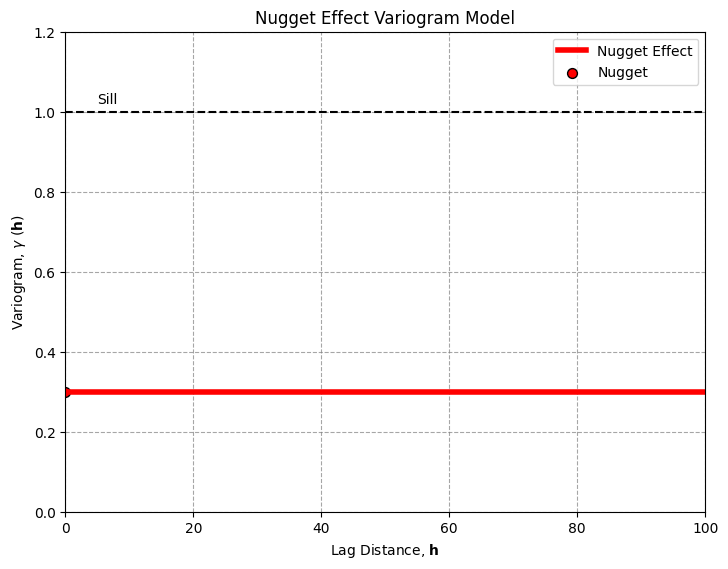

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the nugget effect
nugget_value = 0.3
gamma_nugget = np.ones(101) * nugget_value                    # nugget effect set to 0.3
h = np.linspace(0, 400, 101)                                  # lag distance vector

plt.figure(figsize = (8, 6))

# Plot the nugget effect line (horizontal line)
plt.plot(h, gamma_nugget, color = 'red', lw = 4, label = 'Nugget Effect')

# Plot the sill line
plt.plot([0, 100], [1.0, 1.0], color = 'black', ls = '--')
plt.annotate('Sill', xy = (5, 1.02))

# Plot the nugget point at lag distance 0
plt.scatter(0, nugget_value, color = 'red', edgecolor = 'black', s = 50, label = 'Nugget')

# Set the limits and labels
plt.xlim([0, 100])
plt.ylim([0, 1.2])
plt.xlabel(r'Lag Distance, $\bf{h}$')
plt.ylabel(r'Variogram, $\gamma$ ($\bf{h}$)')
plt.title('Nugget Effect Variogram Model')

# Add grid and legend
plt.grid(True, linestyle = '--', color = 'grey', alpha = 0.7)
plt.legend()

plt.subplots_adjust(left = 0.1, bottom = 0.1, right = 0.9, top = 0.9, wspace = 0.2, hspace = 0.2)
plt.show()


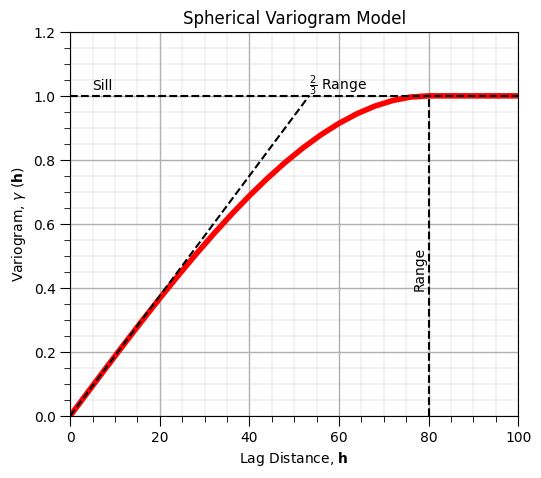

In [ ]:
vrange = 80                                                   # range parameter

gamma_sph = 1.0*(1.5*h/vrange) - 0.5*np.power(h/vrange,3)     # spherical model
gamma_sph[h > vrange] = 1.0

plt.subplot(111)
plot = plt.plot(h,gamma_sph,color = 'red',lw = 4)
plt.plot([0,100],[1.0,1.0],color = 'black',ls = '--'); plt.annotate('Sill',[5,1.02])
plt.plot([0,vrange*2/3],[0,1.0],color = 'black',ls = '--'); plt.annotate(r'$\frac{2}{3}$ Range',[vrange*2/3,1.02])
plt.plot([vrange,vrange],[0.0,1.0],color = 'black',ls = '--'); plt.annotate('Range',[vrange-3.5,0.4],rotation = 90.0)
gca = plt.gca()
plt.xlim([0,100]); plt.ylim([0,1.2])
plt.xlabel(r'Lag Distance, $\bf{h}$'); plt.ylabel(r'Variogram, $\gamma$ ($\bf{h}$)')
plt.title('Spherical Variogram Model'); add_grid()

plt.subplots_adjust(left = 0.0, bottom = 0.0, right = 0.7, top = 0.8, wspace = 0.2, hspace = 0.2); plt.show()

#### Exponential Variogram Model

Also very commonly observed variogram / spatial continuity form

* Less short-scale continuity than spherical, and reaches sill asymptotically, range is at 95% of the sill

The equation:

$$
\gamma( \bf{h} ) = c_1 \cdot \text{ Exp } \left( \frac{ \bf{h} }{𝑎} \right) = c_1 \cdot \left[ 1.0 − \text{exp} \left(−3 \cdot \left( \frac{ \bf{h} }{𝑎} \right) \right) \right]
$$

where $𝑐_1$ is the contribution, $𝑎$ is the range and $\bf{h}$ is the lag distance.

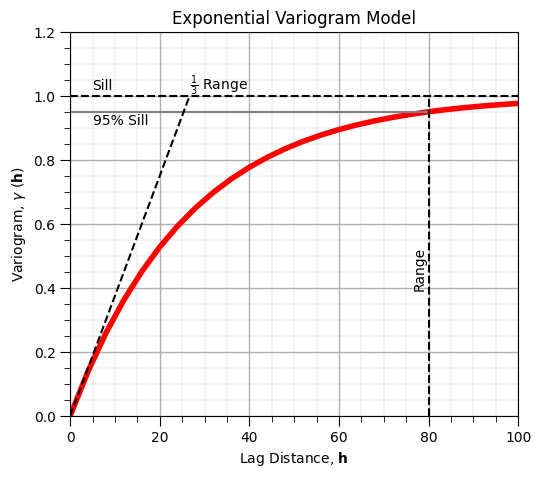

In [ ]:
vrange = 80                                                   # range parameter

gamma_exp = 1.0*(1.0-np.exp(-3*(h/vrange)))                   # exponential model

plt.subplot(111)
plot = plt.plot(h,gamma_exp,color = 'red',lw = 4)
plt.plot([0,100],[1.0,1.0],color = 'black',ls='--'); plt.annotate('Sill',[5,1.02])
plt.plot([0,vrange],[0.95,0.95],color = 'grey',ls = '-'); plt.annotate('95% Sill',[5,0.91])
plt.plot([vrange,vrange],[0.0,1.0],color = 'black',ls = '--'); plt.annotate('Range',[vrange-3.5,0.4],rotation = 90.0)
plt.plot([0,vrange*1/3],[0,1.0],color = 'black',ls = '--'); plt.annotate(r'$\frac{1}{3}$ Range',[vrange*1/3,1.02])
gca = plt.gca()
plt.xlim([0,100]); plt.ylim([0,1.2])
plt.xlabel(r'Lag Distance, $\bf{h}$'); plt.ylabel(r'Variogram, $\gamma$ ($\bf{h}$)')
plt.title('Exponential Variogram Model'); add_grid()

plt.subplots_adjust(left = 0.0, bottom = 0.0, right = 0.7, top = 0.8, wspace = 0.2, hspace = 0.2); plt.show()

#### Gaussian Variogram Model

Less commonly observed variogram / spatial continuity form, e.g., for thickness and elevation

* Much more short-scale continuity than spherical, and reaches sill asymptotically, range is at 95% of the sill

The equation:

$$
\gamma( \bf{h} ) = c_1 \cdot \text{ Gaus } \left( \frac{ \bf{h} }{𝑎} \right) = c_1 \cdot \left[ 1.0 − \text{exp} \left(−3 \cdot \left( \frac{ \bf{h} }{𝑎} \right)^2 \right) \right]
$$

where $𝑐_1$ is the contribution, $𝑎$ is the range and $\bf{h}$ is the lag distance.

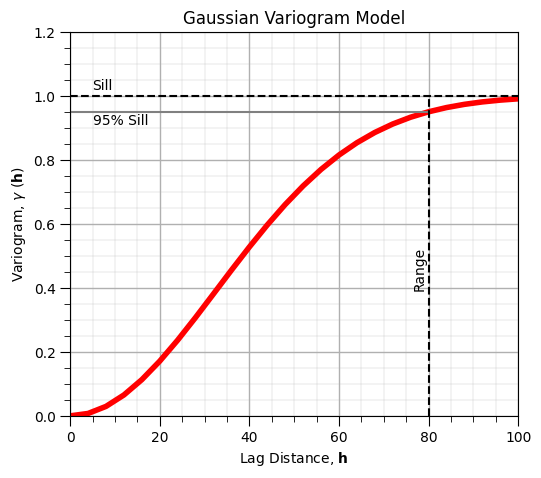

In [ ]:
vrange = 80                                                   # range parameter

gamma_gaus = 1.0*(1.0-np.exp(-3*np.power(h/vrange,2)))        # Gaussian model

plt.subplot(111)
plot = plt.plot(h,gamma_gaus,color = 'red',lw = 4)
plt.plot([0,100],[1.0,1.0],color = 'black',ls = '--'); plt.annotate('Sill',[5,1.02])
plt.plot([0,vrange],[0.95,0.95],color = 'grey',ls = '-'); plt.annotate('95% Sill',[5,0.91])
plt.plot([vrange,vrange],[0.0,1.0],color = 'black',ls = '--'); plt.annotate('Range',[vrange-3.5,0.4],rotation = 90.0)
gca = plt.gca()
plt.xlim([0,100]); plt.ylim([0,1.2])
plt.xlabel(r'Lag Distance, $\bf{h}$'); plt.ylabel(r'Variogram, $\gamma$ ($\bf{h}$)')
plt.title('Gaussian Variogram Model'); add_grid()

plt.subplots_adjust(left = 0.0, bottom = 0.0, right = 0.7, top = 0.8, wspace = 0.2, hspace = 0.2); plt.show()

 x,y,z offsets = 7.071067805519558,7.071067818211393
 x,y,z offsets = 7.071067830903227,-7.071067792827723


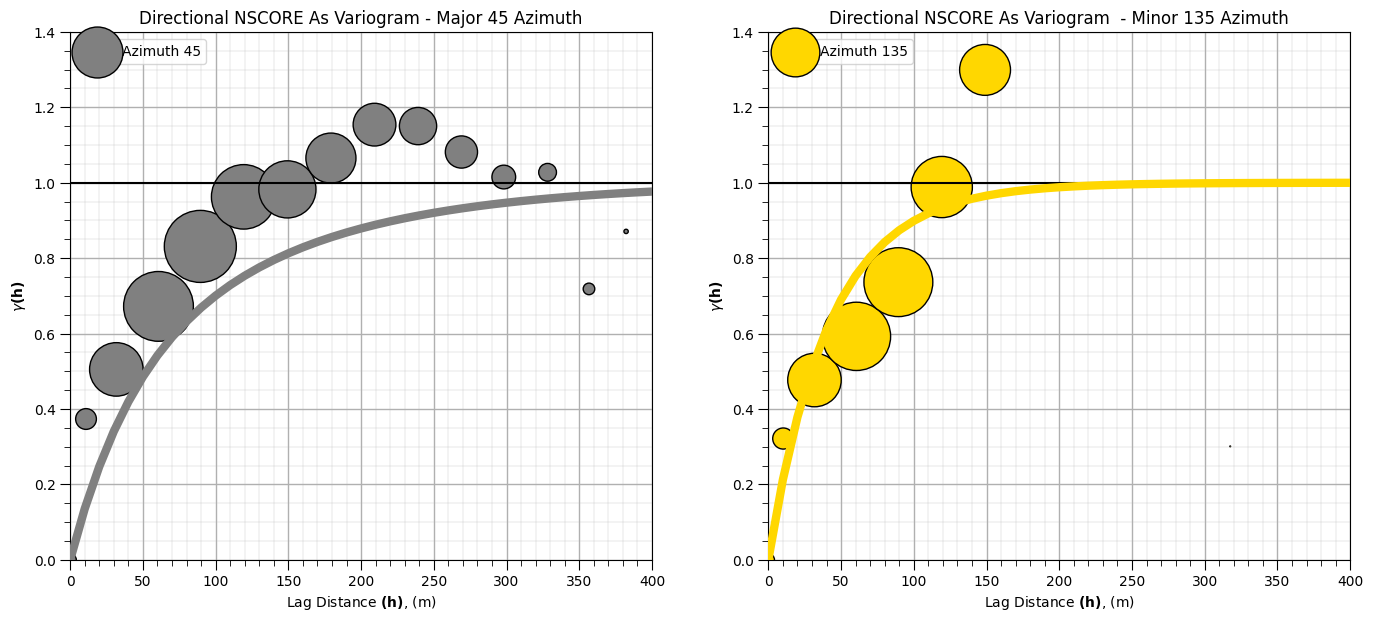

In [47]:
nug = 0.0; nst = 2                                             # 2 nest structure variogram model parameters
it1 = 2; cc1 = 0.4; azi1 = azi_mat[imajor]; hmaj1 = 120; hmin1 = 100
it2 = 2; cc2 = 0.6; azi2 = azi_mat[imajor]; hmaj2 = 370; hmin2 = 150

vario = GSLIB.make_variogram(nug,nst,it1,cc1,azi1,hmaj1,hmin1,it2,cc2,azi2,hmaj2,hmin2) # make model object
nlag = 70; xlag = 10;                                          # project the model in the 045 azimuth
index_maj,h_maj,gam_maj,cov_maj,ro_maj = geostats.vmodel(nlag,xlag,azi_mat[imajor],vario)                                                     # project the model in the 135 azimuth
index_min,h_min,gam_min,cov_min,ro_min = geostats.vmodel(nlag,xlag,azi_mat[iminor],vario)

plt.subplot(1,2,1)
plt.scatter(lag[imajor,:],gamma[imajor,:],color = 'grey',edgecolor = 'black',s = npp[imajor,:]/20,marker = 'o',label = 'Azimuth ' +str(azi_mat[imajor]))
plt.plot([0,2000],[1.0,1.0],color = 'black')
plt.plot(h_maj,gam_maj,color = 'grey',lw = 6,zorder = 60)
plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Directional NSCORE As Variogram - Major ' + str(azi_mat[imajor]) + ' Azimuth')
plt.xlim([0,400])
plt.ylim([0,1.4])
plt.legend(loc = 'upper left')
add_grid()

plt.subplot(1,2,2)
plt.scatter(lag[iminor,:],gamma[iminor,:],color = 'gold',edgecolor = 'black',s=npp[iminor,:]/20,marker = 'o',label = 'Azimuth ' +str(azi_mat[iminor]))
plt.plot([0,2000],[1.0,1.0],color = 'black')
plt.plot(h_min,gam_min,color = 'gold',lw = 6,zorder = 60,)
plt.xlabel(r'Lag Distance $\bf(h)$, (m)')
plt.ylabel(r'$\gamma \bf(h)$')
plt.title('Directional NSCORE As Variogram  - Minor ' + str(azi_mat[iminor]) + ' Azimuth')
plt.xlim([0,400])
plt.ylim([0,1.4])
plt.legend(loc = 'upper left')
add_grid()
plt.subplots_adjust(left = 0.0, bottom = 0.0, right = 2.0, top = 1.1, wspace = 0.2, hspace = 0.3); plt.show()

# Week 3 Assignment

# Week 3 Practical: Declustering, Normal Scores, and Variography (Cu %)

**Context.** You are given point‐sample Copper grades expressed in **percent (%)** with X–Y (and, if available, Z) coordinates. The goal this week is to correct for spatial sampling bias via **cell declustering**, compare naïve vs. declustered statistics, transform grades to **Gaussian (normal) scores**, compute an **experimental variogram**, and **fit** a suitable model (choose from **Spherical, Exponential, Gaussian**).

> ✅ **Deliver everything in a single Jupyter notebook.** Use clear section headings, show intermediate diagnostics (plots + tables), and finish with a short written report (template provided at the end).


## Learning outcomes

By the end of this practical you should be able to:

1. Explain why clustered sampling biases global statistics, and correct it with **cell declustering**.
2. Compute and compare **naïve** vs **declustered** mean, variance, and histogram.
3. Map empirical Cu% values to **normal scores** using the **normal score transform** and check the result.
4. Build an **experimental variogram** from normal scores, with sensible lag parameters.
5. **Fit** a Spherical, Exponential, and Gaussian **variogram model**, justify your choice, and report the parameters (nugget, sill, range).


## Data & setup

* Input table must contain at least: `x`, `y`, `Cu_pct`. If `z` exists, ignore for this week (2D).
* Keep grades in **% units** for declustering and summary stats. For variography, use **normal scores**.
* Recommended packages: `numpy`, `pandas`, `scipy`, `matplotlib`. (Optional: `gstools` or `scikit-gstat`.)



## Task 1: Cell declustering (de-biasing)

**Why.** Clustered sampling (e.g., near roads or pits) overweights those zones and biases global stats.

**Method (grid-based cell declustering).**

1. Choose a **cell size** close to **half the average nearest‐neighbour distance**. Tip: compute NND and use its median; try a few sizes around that value (sensitivity check).
2. Overlay a regular grid; count samples per cell.
3. Assign each sample a weight
   $
   w_i ;=; \frac{1}{n_c} \quad \text{for sample } i \text{ in cell } c,\quad \text{then normalise } \sum_i w_i = 1.
   $
4. **Sensitivity:** Pick the size that stabilises the weighted mean.

**Outputs.**

* Scatter plot of sample locations colour‐coded by weight (heavier in sparse areas).
* Table of naïve vs declustered stats: mean, std, min, p10, p50, p90, max.
* Overlaid histograms of Cu%: naïve (equal weights) vs declustered (w_i).



## Task 2: Normal score transform (to Gaussian)

**Why.** Variogram modelling and many geostatistical methods assume normality.

**Steps.**

1. Compute the **empirical CDF** of Cu% using **rank‐based** probabilities
   $
   p_i = \frac{\text{rank}(z_i) - 0.5}{N},
   $
   using average ranks for ties.
2. Map to normal scores
   $
   y_i ;=; \Phi^{-1}(p_i),
   $
   where $\Phi^{-1}$ is the standard normal quantile.


## Task 3: Experimental variogram

Compute the semivariance on **normal scores** (y):

$
\gamma(h) ;=; \frac{1}{2,N(h)} \sum_{(i,j)\in \mathcal{P}(h)} \bigl(y(\mathbf{x}_i)-y(\mathbf{x}_j)\bigr)^2,
$

where $\mathcal{P}(h)$ are all pairs whose separation falls into the lag bin for distance (h).


**Outputs.** Experimental semi-variogram plots.


## Task 4: Variogram model fitting & selection

Fit **all three** models to the experimental variogram (on normal scores) and select the best with a clear justification.

**Models (nested form with single or double structure is fine this week):**

* **Spherical**
  $
  \gamma(h) = C_0 + C\left[ \tfrac{3}{2}\tfrac{h}{a} - \tfrac{1}{2}\Bigl(\tfrac{h}{a}\Bigr)^3 \right] \ \text{for } h\le a,\quad
  \gamma(h) = C_0 + C \ \text{for } h > a.
  $

* **Exponential**
  $
  \gamma(h) = C_0 + C\left(1 - e^{-h/a}\right),
  \quad \text{practical range } \approx 3a.
  $

* **Gaussian**
  $
  \gamma(h) = C_0 + C\left(1 - e^{-(h/a)^2}\right),
  \quad \text{practical range } \approx \sqrt{3},a.
  $

Here $C_0$ = **nugget**, $C$ = **structured sill contribution**, $C_0+C$ = **total sill**, $a$ = **range parameter**.

**Fitting hints.**

* Initial guesses:

  * $C_0$ ≈ first‐lag $\gamma$ (or 10–20% of total sill if noisy)
  * total sill ≈ 1


**Outputs.** Variogram plot with empirical points and all three fitted curves; a small table of fitted parameters per model.


## What to hand in (minimum)

1. **Notebook sections:**

   * Data load and quick EDA (spatial scatter; histogram of Cu%).
   * **Cell declustering** (weights map; naïve vs declustered summary and histograms; sensitivity to cell size).
   * **Normal score transform** (histogram PDF and CDF‐plot, (z) vs (y)).
   * **Experimental variograms** (plots).
   * **Model fitting** (Spherical, Exponential, Gaussian; parameter table; final chosen model).
2. **Figures**: clear axis labels/units; legends; readable fonts.
3. **Markdown report** at the very end (use the template below).


### Submission checklist

* [ ] Notebook runs top-to-bottom without errors.
* [ ] All plots/tables are labelled and legible.
* [ ] Final Markdown report completed.

Good luck! and remember: **show your working**, not just final numbers.
